In [1]:
%matplotlib widget
# Import libraries
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
sc.logging.print_header()
sc.logging.print_memory_usage()
sc.settings.verbosity = 2

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.13.0 pandas==2.0.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13
Memory usage: current 0.57 GB, difference +0.57 GB


## Load Data
Load the single sample (sample 1) matrix.

In [2]:
import os
print(os.getcwd())

/tmp/Mazutislab-out/Juozapas


In [3]:
# Change directory to where the matrices is stored
%cd HEM/data/matrices/

/tmp/Mazutislab-out/Juozapas/HEM/data/matrices


In [4]:
# Load all samples
adatas = {}
for i in range(1, 16):
    adatas[i] = sc.read_10x_mtx(f"{i}")

In [5]:
for i in range(1, 16):
    adatas[i].var['mt'] = (
        adatas[i].var_names.str.startswith("GRCh38_MT-")
    )
    adatas[i].var['ribo'] = (
        adatas[i].var_names.str.startswith("GRCh38_RPL") |
        adatas[i].var_names.str.startswith("GRCh38_RPS") 
    )
    sc.pp.calculate_qc_metrics(adatas[i], qc_vars=['mt', 'ribo'], percent_top=None, inplace=True)

In [ ]:
# Setting count treshholds
INTERACTIVE = True

if INTERACTIVE:
    #show plot 

In [6]:
import ipywidgets as widgets

thresholds = {}
bins=np.logspace(np.log10(10), np.log10(50000), 51)

def show_sample(i):
    data = adatas[i].obs['total_counts']

    fig, ax = plt.subplots()

    ax.hist(data, bins=bins, weights=data)
    ax.set_xscale('log')

    # load previous value if exists
    t0 = thresholds.get(i, 1000)
    vline = ax.axvline(t0, color='red')

    slider = widgets.IntSlider(
        value=t0,
        min=100,
        max=3000,
        step=50,
        description="threshold"
    )

    def update(change):
        thresholds[i] = change["new"]
        vline.set_xdata([change["new"], change["new"]])
        fig.canvas.draw_idle()

    slider.observe(update, names="value")

    display(slider)
    plt.show()

IntSlider(value=1000, description='threshold', max=3000, min=100, step=50)

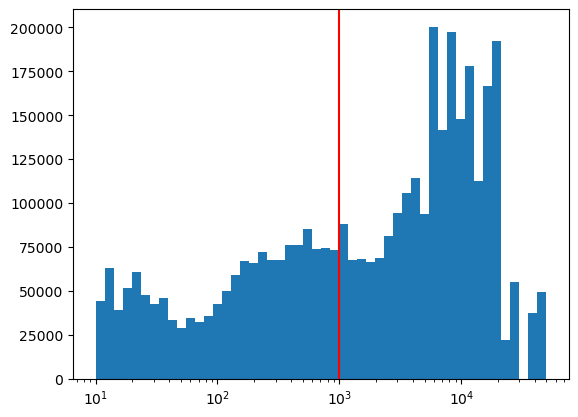

In [7]:
show_sample(5)

In [ ]:
bins = np.logspace(np.log10(10), np.log10(50000), 51)


def plot_sample(i, threshold):
    fig, ax = plt.subplots()

    data = adatas[i].obs['total_counts']

    ax.hist(data, bins=bins, weights=data)
    ax.set_xscale('log')
    ax.axvline(threshold, color='red')

    ax.set_title(f"Sample {i}")
    plt.show()

widgets.interact(
    plot_sample,
    i=widgets.IntSlider(min=1, max=15, step=1, value=1),
    threshold=widgets.IntSlider(min=100, max=3000, step=100, value=1000)
)

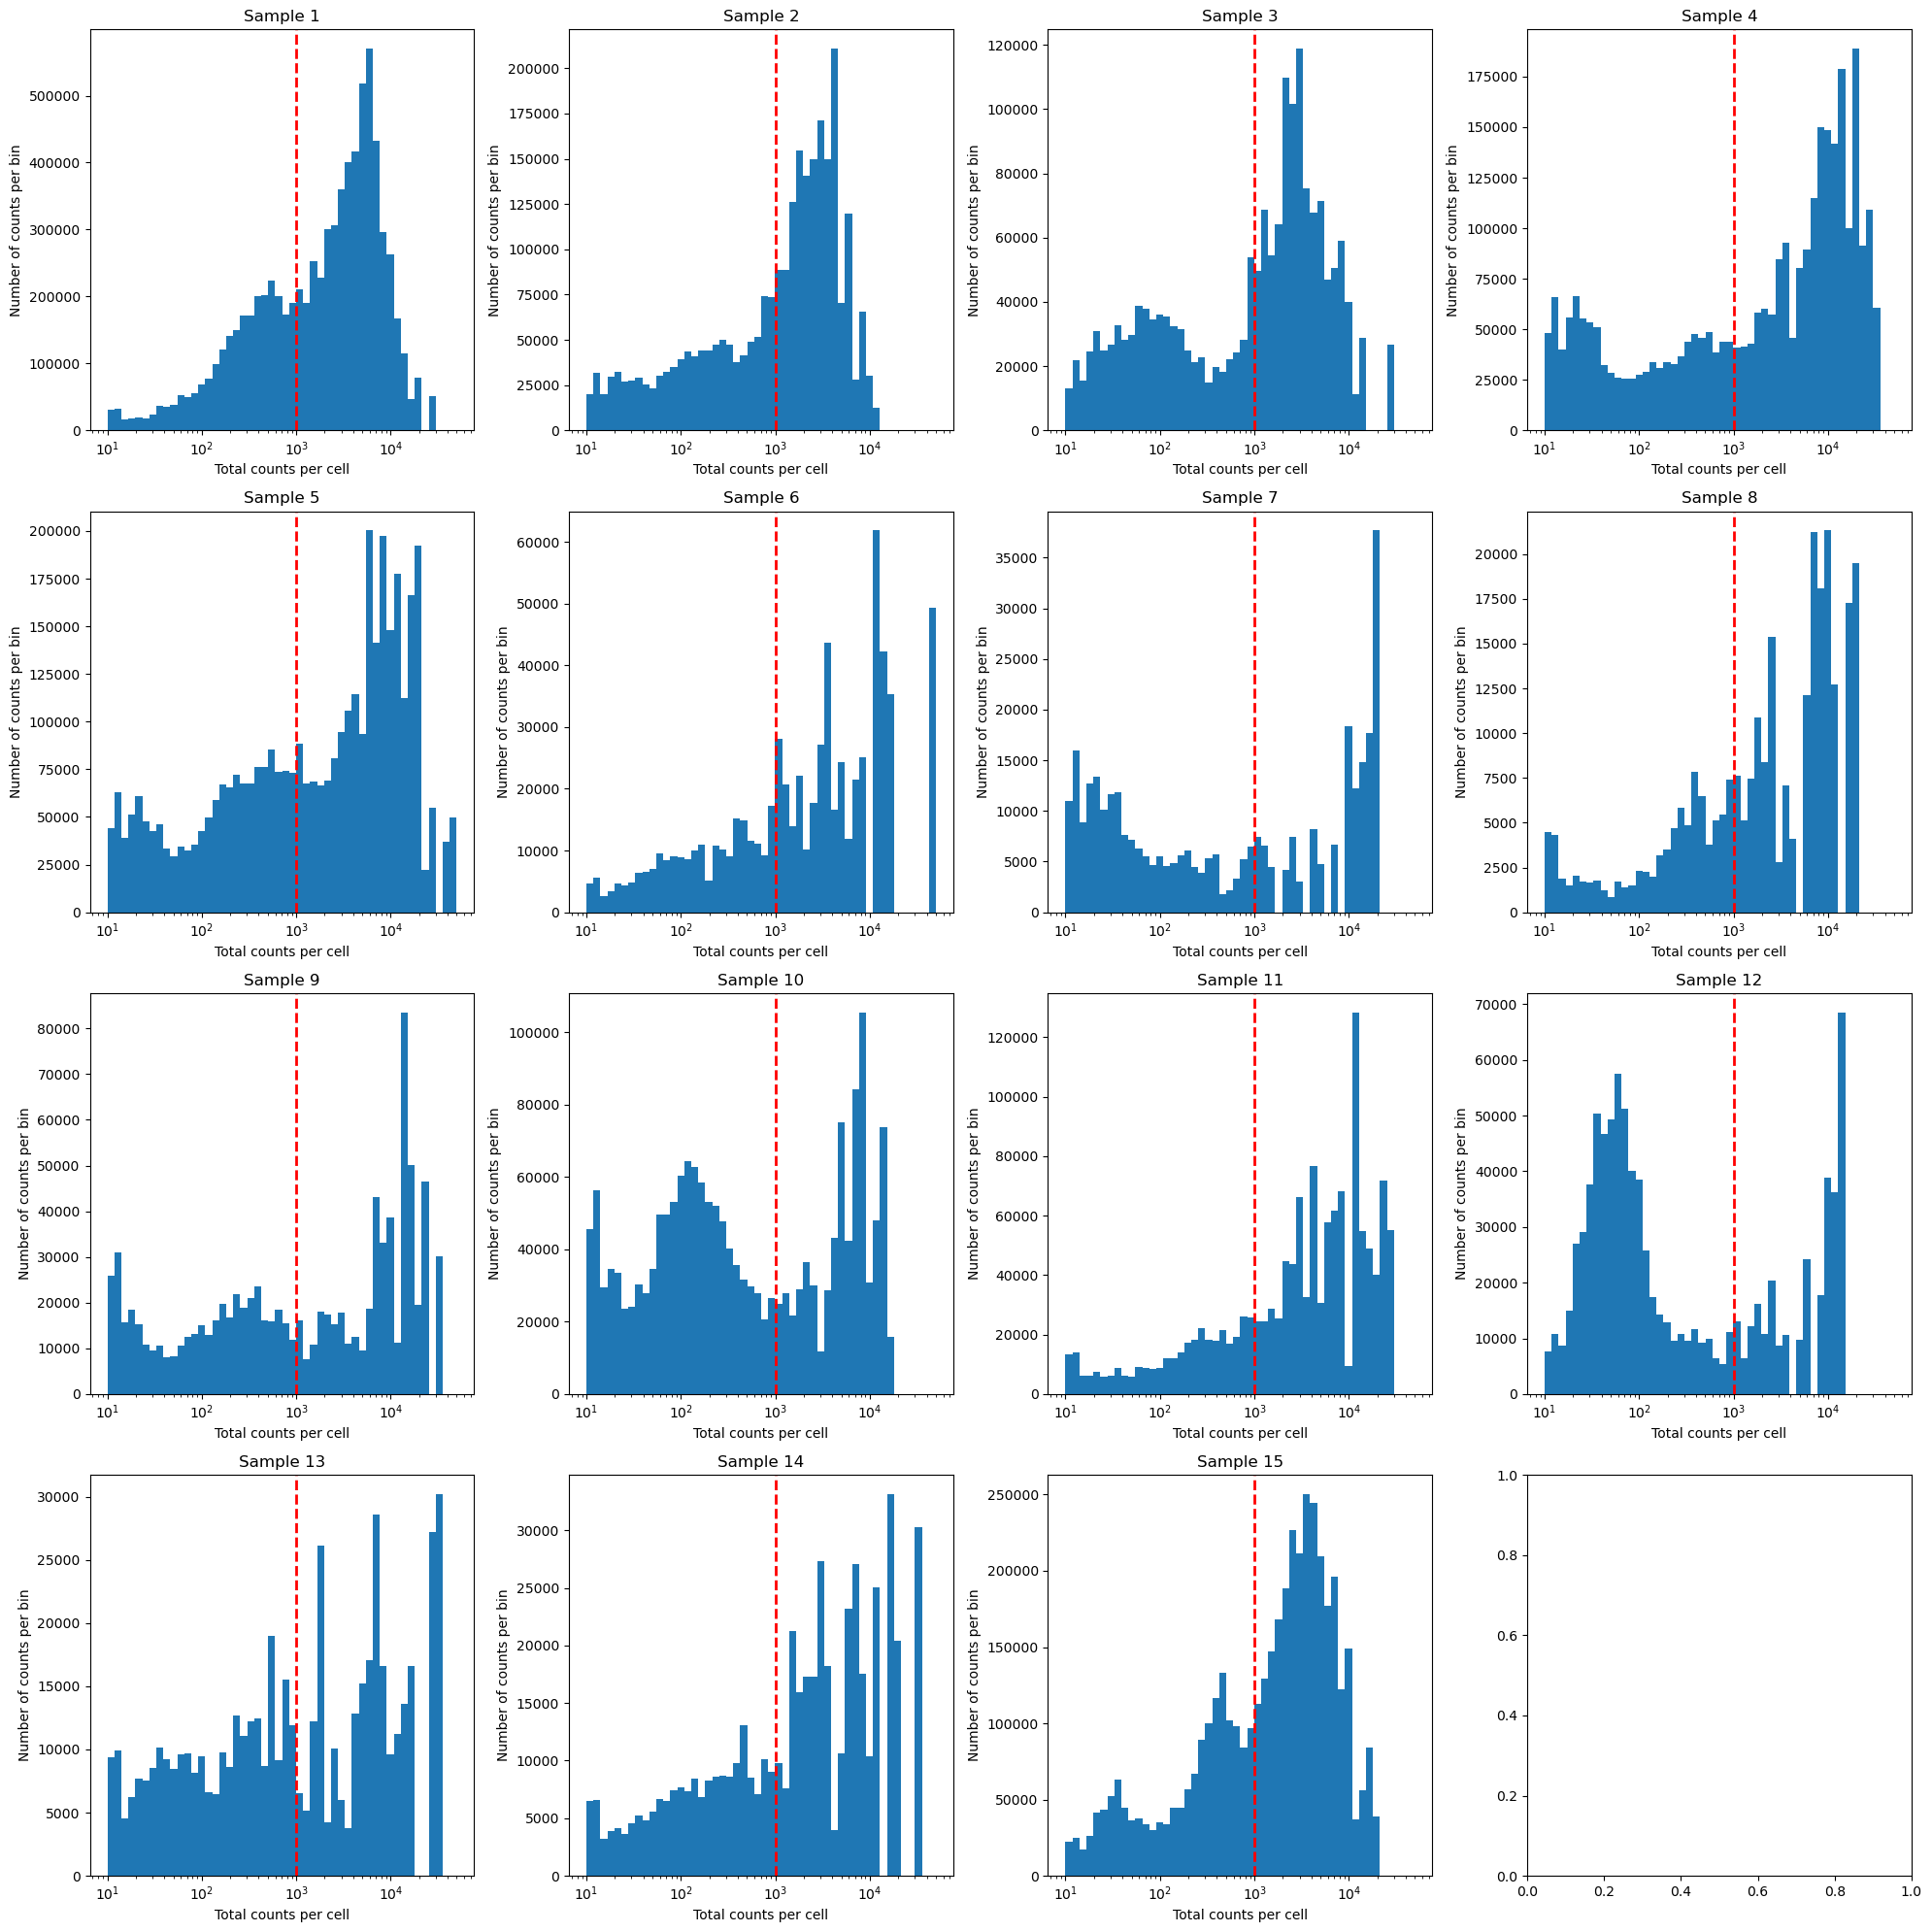

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(20,20))

axes = axes.flatten()

for i in range(15):
    # Plot total counts per cell
    threshold = 1000
    bins = np.logspace(np.log10(10), np.log10(50000), 51)
    axes[i].hist(adatas[i+1].obs['total_counts'], bins=bins, weights=adatas[i+1].obs['total_counts'], )
    axes[i].set_xscale('log')
    axes[i].set_xlabel('Total counts per cell')
    axes[i].set_ylabel('Number of counts per bin')
    axes[i].axvline(x=threshold, color='red', linestyle='dashed', linewidth=2)
    axes[i].set_title(f"Sample {i+1}")

plt.tight_layout()
plt.show()

In [12]:
# Filter cells by total counts
adata = adata[adata.obs['total_counts'] >= threshold].copy()

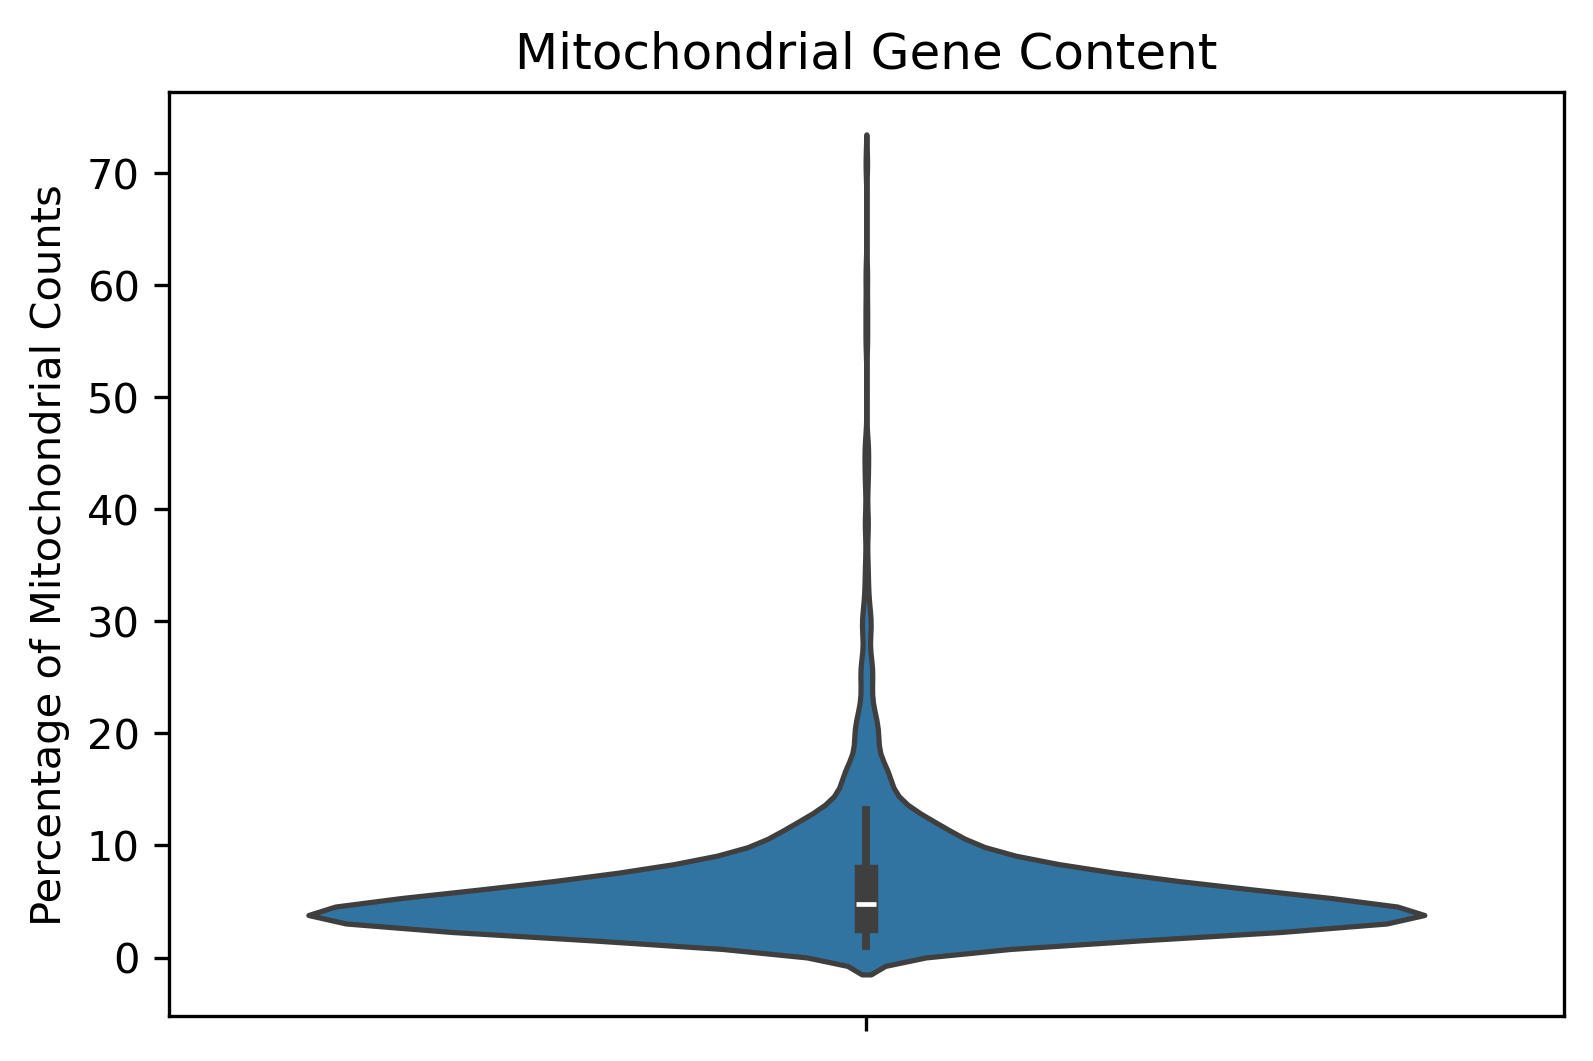

In [13]:
# Plot mitochondrial gene content
plt.figure(figsize=(6,4), dpi=300)
sns.violinplot(y=adata.obs['pct_counts_mt'])
plt.title('Mitochondrial Gene Content')
plt.ylabel('Percentage of Mitochondrial Counts')
plt.show()

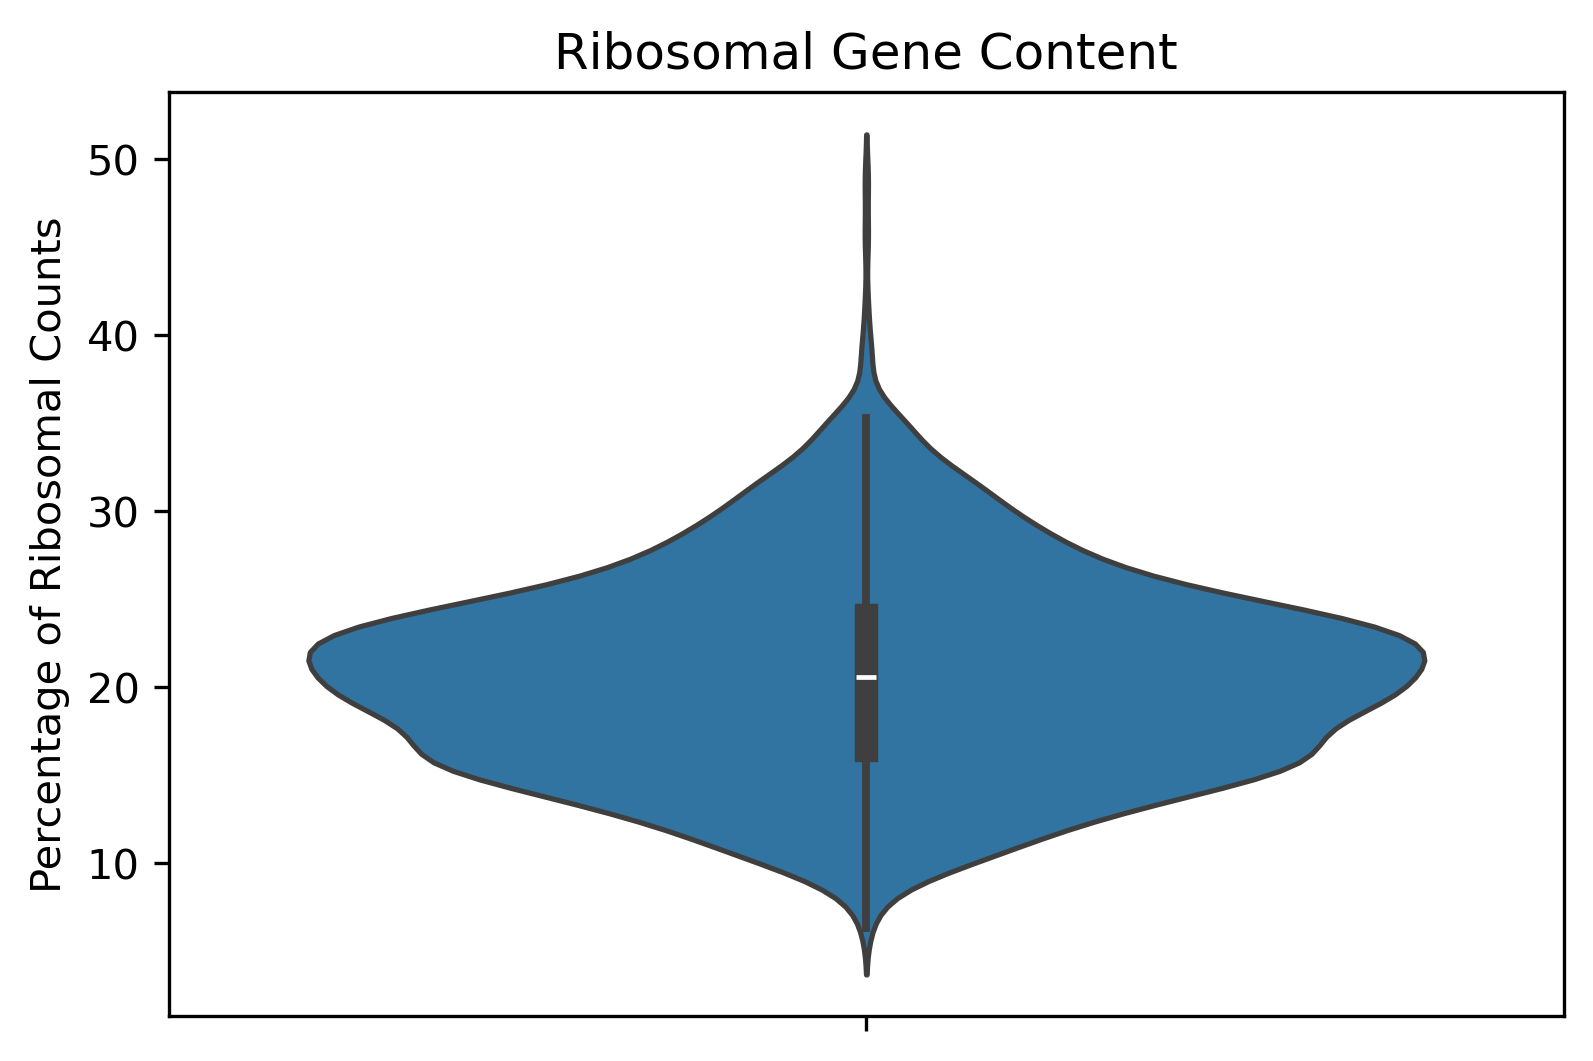

In [14]:
# Plot ribosomal gene content
plt.figure(figsize=(6,4), dpi=300)
sns.violinplot(y=adata.obs['pct_counts_ribo'])
plt.title('Ribosomal Gene Content')
plt.ylabel('Percentage of Ribosomal Counts')
plt.show()

In [15]:
# Filter cells by mitochondrial content and genes
mt_threshold = 20
adata = adata[adata.obs['pct_counts_mt'] < mt_threshold].copy()
sc.pp.filter_genes(adata, min_cells=3)

filtered out 20273 genes that are detected in less than 3 cells


In [16]:
# Preprocessing and UMAP for
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()

normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:00)


computing PCA
    with n_comps=50
    finished (0:00:00)


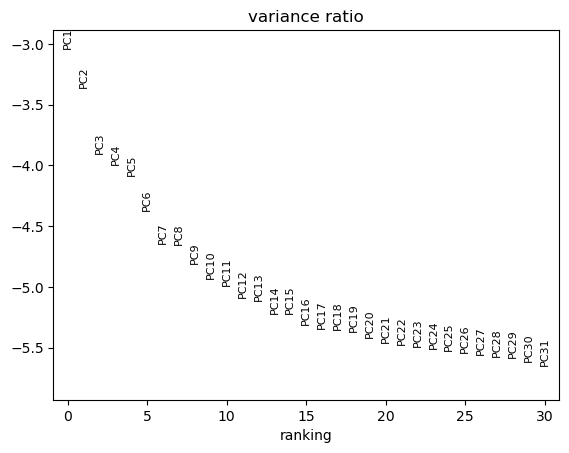

In [17]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, log=True)

computing neighbors
    using 'X_pca' with n_pcs = 15
    finished (0:00:00)
computing UMAP
    finished (0:00:01)


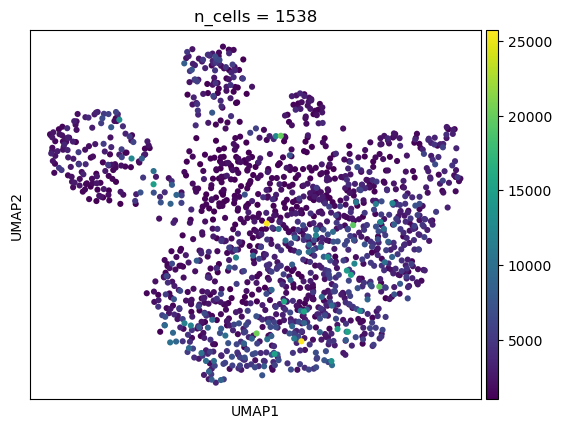

In [21]:
sc.pp.neighbors(adata, n_pcs=15)
sc.tl.umap(adata)
sc.pl.umap(adata, title=f"n_cells = {adata.n_obs}", color='total_counts')

In [17]:
adata

AnnData object with n_obs × n_vars = 1538 × 2571
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
# Save processed AnnData object for sample 1
adata.write("1_processed.h5ad")